Players: 100
K-MEANS CLUSTERING (k = 2)
Silhouette Score: 0.343

Cluster Summary:
                     SR    AVG    RUNS  SIXES  Price_Cr
cluster_name                                           
High Performers  163.72  37.89  392.31  20.53     10.97
Low Performers   127.04  18.85  106.29   5.09      4.44

Cluster Counts:
cluster_name
Low Performers     55
High Performers    45
Name: count, dtype: int64


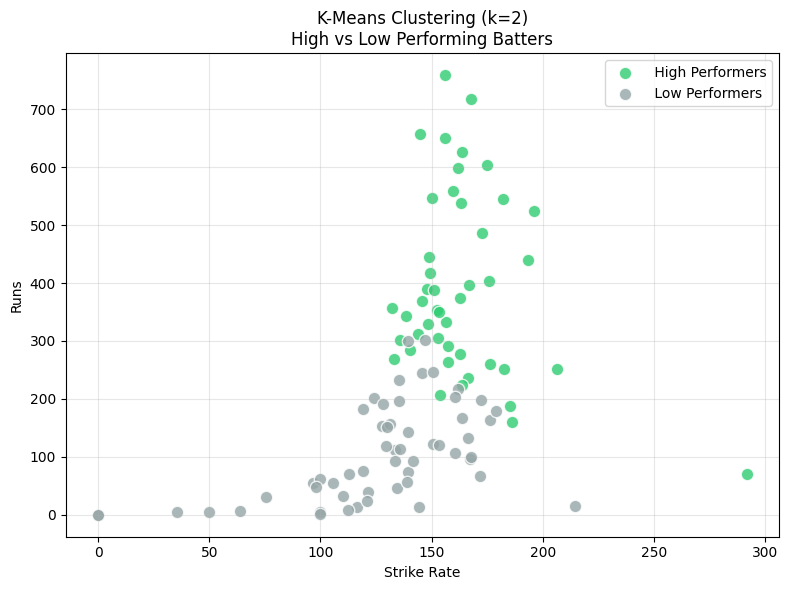

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

bat = pd.read_csv("cleaned_batters.csv")
ar  = pd.read_csv("cleaned_allrounders.csv")

all_bat = pd.concat([
    bat[['Player','Team','Abbr','Price_Cr','RUNS','AVG','SR','SIXES']],
    ar[['Player','Team','Abbr','Price_Cr','RUNS','Bat_AVG','Bat_SR','SIXES']]
        .rename(columns={'Bat_AVG':'AVG','Bat_SR':'SR'})
], ignore_index=True).dropna()

print(f"Players: {len(all_bat)}")
print("=" * 50)
print("K-MEANS CLUSTERING (k = 2)")
print("=" * 50)

features = ['SR','AVG','RUNS','SIXES','Price_Cr']
X = all_bat[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
all_bat['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, all_bat['cluster'])
print(f"Silhouette Score: {sil:.3f}")

cluster_runs = all_bat.groupby("cluster")["RUNS"].mean()

high_perf_cluster = cluster_runs.idxmax()
low_perf_cluster  = cluster_runs.idxmin()

all_bat["cluster_name"] = all_bat["cluster"].map({
    high_perf_cluster: " High Performers",
    low_perf_cluster: " Low Performers"
})

print("\nCluster Summary:")
print(all_bat.groupby("cluster_name")[features].mean().round(2))

print("\nCluster Counts:")
print(all_bat["cluster_name"].value_counts())

plt.figure(figsize=(8,6))

colors = {
    " High Performers": "#2ECC71",
    " Low Performers": "#95A5A6"
}

for name, grp in all_bat.groupby("cluster_name"):
    plt.scatter(
        grp["SR"], grp["RUNS"],
        color=colors[name],
        s=80, alpha=0.8,
        edgecolors="white",
        label=name
    )

plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.title("K-Means Clustering (k=2)\nHigh vs Low Performing Batters")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

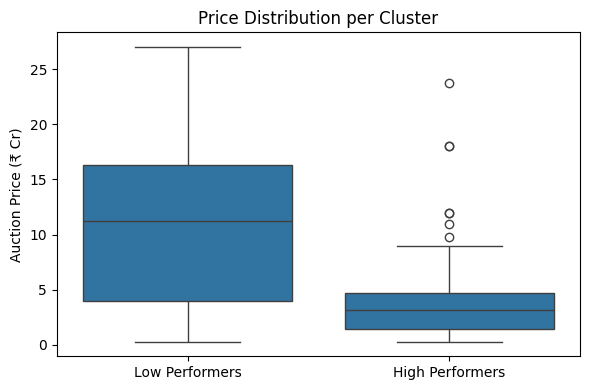

In [ ]:
plt.figure(figsize=(6,4))

cluster_names = {
    0: "High Performers",
    1: "Low Performers",
}

all_bat["cluster_name"] = all_bat["cluster"].map(cluster_names)

import seaborn as sns

sns.boxplot(
    data=all_bat,
    x="cluster_name",
    y="Price_Cr"
)

plt.xlabel("")
plt.ylabel("Auction Price (₹ Cr)")
plt.title("Price Distribution per Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()